## Data prep

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import sys
import numpy as np
from pathlib import Path

from tqdm.auto import tqdm

%config InlineBackend.figure_format = 'svg'


We then import the data that we will need for our inflation rate forecasting

In [2]:
BSP_CPI = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/bsp_cpibase2018_dataset.csv")
USD_PHP = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/usd_to_php.csv")
Unemployment = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/psa_unemployment_rate.csv")
Crude_Oil = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/global_dubai_crude.csv")
Target_RRP = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/raw/target_rrp.csv")

Inflation rate can be calculated from CPI data

$$
\text{Inflation} = \dfrac{\text{CPI}_{\text{current}} - \text{CPI}_{\text{previous}}}{\text{CPI}_{\text{current}}} \times 100
$$

In [3]:
# CPI / Inflation
BSP_CPI['Date'] = pd.to_datetime(BSP_CPI['Year'].astype(str) + ' ' + BSP_CPI['Month'] + ' 1')
BSP_CPI.rename(columns={'All Items': 'CPI'}, inplace=True)
BSP_CPI = BSP_CPI[['Date', 'CPI']].sort_values('Date')
BSP_CPI['InflationRate'] = BSP_CPI['CPI'].pct_change(12) * 100
BSP_CPI = BSP_CPI[['Date', 'InflationRate']]

# USD/PHP
USD_PHP['Year'] = USD_PHP['Period'].ffill()
USD_PHP['Date'] = pd.to_datetime(USD_PHP['Year'].astype(int).astype(str) + ' ' + USD_PHP['Unnamed: 1'] + ' 1')
USD_PHP = USD_PHP[['Date', 'Average']].rename(columns={'Average': 'USD_PHP'})

# Unemployment
Unemployment['Date'] = pd.to_datetime(Unemployment['Year'].astype(str) + ' ' + Unemployment['Monthly/Quarterly'] + ' 1')
Unemployment['Unemployment Rate'] = pd.to_numeric(Unemployment['Unemployment Rate'], errors='coerce')
Unemployment = Unemployment[['Date', 'Unemployment Rate']].rename(columns={'Unemployment Rate': 'UnemploymentRate'}).sort_values('Date')
Unemployment['UnemploymentRate'] = Unemployment['UnemploymentRate'].ffill(limit_area='inside')

# Dubai crude oil
Crude_Oil['Date'] = pd.to_datetime(Crude_Oil['observation_date'], format='%d/%m/%Y')
Crude_Oil = Crude_Oil[['Date', 'POILDUBUSDM']].rename(columns={'POILDUBUSDM': 'DubaiCrude'})

# Target RRP
Target_RRP['Date'] = pd.to_datetime(Target_RRP['Date'], format='%d/%m/%Y')
Target_RRP['Rate'] = pd.to_numeric(Target_RRP['Rate'], errors='coerce')
Target_RRP = Target_RRP.dropna(subset=['Rate'])
Target_RRP = Target_RRP.sort_values('Date')
Target_RRP = Target_RRP.groupby(pd.Grouper(key='Date', freq='MS')).last().reset_index()
Target_RRP = Target_RRP.rename(columns={'Rate': 'TargetRRP'})
# Merge
INF_data = BSP_CPI.merge(USD_PHP, on='Date', how='outer') \
                  .merge(Unemployment, on='Date', how='outer') \
                  .merge(Crude_Oil, on='Date', how='outer') \
                  .merge(Target_RRP, on='Date', how='outer') \
                  .sort_values('Date') \
                  .reset_index(drop=True)
INF_data.set_index('Date', inplace=True)

start = INF_data['InflationRate'].first_valid_index()
end = INF_data.dropna(how='all').index[-1]
INF_data = INF_data.loc[start:end]

In [4]:
processed_dir = '/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/processed/'
processed_file_path = os.path.join(processed_dir, 'Combined_Macro_Data.csv')

os.makedirs(processed_dir, exist_ok=True)
INF_data.to_csv(processed_file_path, index=True)

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

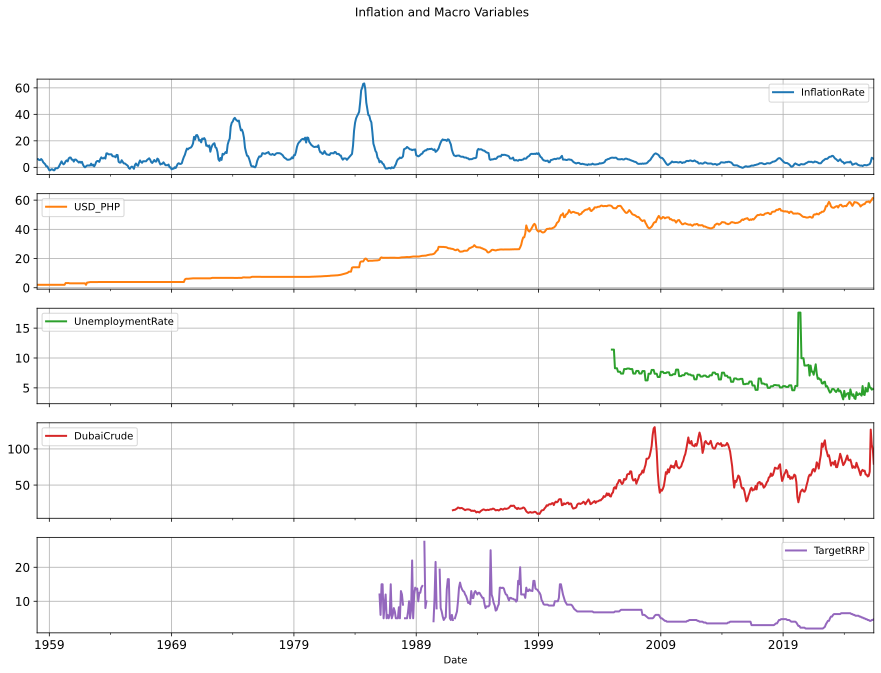

In [18]:
INF_data.plot(subplots=True, figsize=(15, 10), title='Inflation and Macro Variables', grid=True, linewidth=2, fontsize=12)

## Exploratory Data Analysis

In [37]:
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [21]:
INF_data.index = pd.to_datetime(INF_data.index)
INF_data.head()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
Date,,,,,
1958-01-01,6.25000,2.0,NaN,NaN,NaN
1958-02-01,6.25000,2.0,NaN,NaN,NaN
1958-03-01,5.46875,2.0,NaN,NaN,NaN
1958-04-01,5.46875,2.0,NaN,NaN,NaN
1958-05-01,6.25000,2.0,NaN,NaN,NaN


In [22]:
# making a folder for all outputs

output_dir = "/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/output_files"
output_path = os.path.join(output_dir, 'YY_INF_RATE.png')

os.makedirs(output_dir, exist_ok=True)

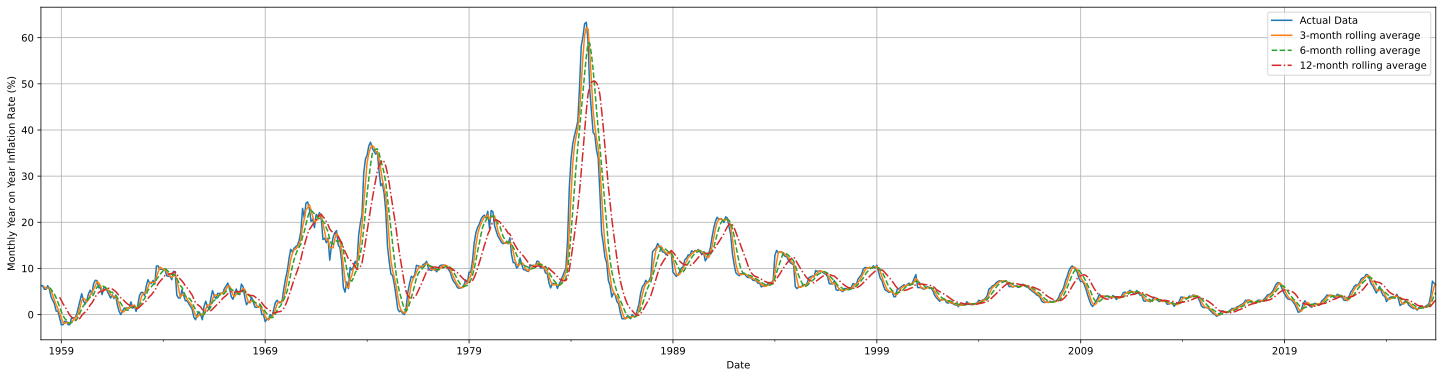

In [23]:
INF_rate = INF_data['InflationRate'].dropna()

plt.figure(figsize=(25,6))

INF_rate.plot(label = 'Actual Data')
INF_rate.rolling(3).mean().plot(linestyle = '-', label = '3-month rolling average')
INF_rate.rolling(6).mean().plot(linestyle = '--', label = '6-month rolling average')
INF_rate.rolling(12).mean().plot(linestyle = '-.', label = '12-month rolling average')

plt.ylabel('Monthly Year on Year Inflation Rate (%)')
plt.grid(True)
plt.legend()
plt.savefig(output_path, dpi=300, bbox_inches='tight')


- The blue line shows the actual data. It represents the raw monthly YoY inflation values over time. 

- The solid orange line lags the actual data via 3-months. 

- The Dashed green line lags the actual data slightly but highlights medium term momentum shifts and persistent trends.

- The Dash-Dot red line lags the actual data further behind, outlining structural inflation regimes and long term trend directions. 

Rolling averages are used to smooth out short-term fluctuations to reveal the underlying long-term trend. 

In [ ]:
print(INF_rate.describe())

print('Skewness: {:.5f}'.format(INF_rate.skew())) # measure of asymmetry of the data
print('Kurtosis: {:.5f}'.format(INF_rate.kurt())) # measure the peakness and weight of the tails

count    822.000000
mean       7.908864
std        8.406149
min       -2.205882
25%        3.009064
50%        5.812458
75%        9.803922
max       63.333333
Name: InflationRate, dtype: float64
Skewness: 2.96633
Kurtosis: 12.26615


- **Positive skew** means the data has a long tail on the right side -- high inflation spikes

- **Negative skew** means the data has a long tail on the left side -- high deflation spikes

- **High kurtosis** -- data has very sharp peaks and fat tails. Extreme inflation or deflation shocks happen more frequently than you would expect.

- **Low kurtosis** -- data has flat top and thin tails. Outliers are rare. 

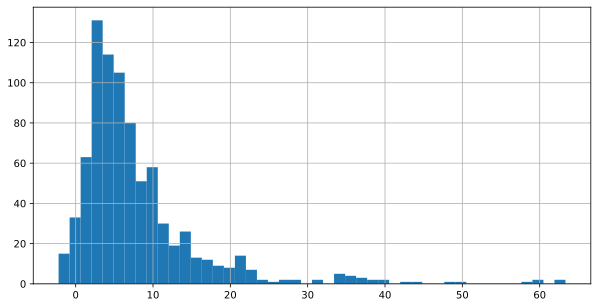

In [25]:
# let us plot a histogram

plt.figure(figsize=(10, 5))
INF_rate.hist(bins = 'fd')
plt.savefig(os.path.join(output_dir, 'YY_INF_RATE_HISTOGRAM.png'), dpi = 300, bbox_inches = 'tight')
plt.show()

The histogram confirms the high kurtosis and skewdness of the data set. 

We now want to test for stationarity. 

In [27]:
resultADF = adfuller(INF_rate, result_object=True)

print(f"ADF Statistic: {resultADF[0]:.4f}")
print(f"p-value:       {resultADF[1]:.6f}")
print("Critical Values:")
for key, value in resultADF.critical_values.items():
    print(f"   {key}: {value:.4f}")
print(f"IC Best:       {resultADF.icbest:.4f}")

ADF Statistic: -4.3947
p-value:       0.000303
Critical Values:
   1%: -3.4386
   5%: -2.8652
   10%: -2.5687
IC Best:       2561.9994


The ADF test determines if the time series is stationary or non-stationary. 

**Stationary Data** : The mean, variance, and autocorrelation structure remain constant over time. 

Null Hypothesis $H_0$ means the series has a unit root.\
Alternative Hypothesis $H_1$ means that there is no unit root. 

**WHAT THE NUMBERS TELL**
- ADF test stat - strength signal of the test. the more negative the number the stronger the evidence against null hypothesis. 
- p-value - probability that the data contains a unit root by random choice. 
- critical values - 1%, 5%, 10%

TAKEAWAYS : the data shows that it is indeed a stationary series. This makes it a good dataset to use for models like VAR or ARIMA, etc. 

In [28]:
resultKPSS = kpss(INF_rate, result_object=True)
print(f"KPSS Statistic: {resultKPSS.statistic:.4f}")
print(f"p-value:        {resultKPSS.pvalue:.6f}")
print(f"Lags:           {resultKPSS.lags}")
print("Critical Values:")
for key, value in resultKPSS.critical_values.items():
    print(f"   {key}: {value:.5f}")

KPSS Statistic: 0.7671
p-value:        0.010000
Lags:           17
Critical Values:
   10%: 0.34700
   5%: 0.46300
   2.5%: 0.57400
   1%: 0.73900


/var/folders/04/ps2hpxjs3ld348n6zjycrvx80000gn/T/ipykernel_39767/969368597.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  resultKPSS = kpss(INF_rate, result_object=True)


Notice now however that we have a KPSS statistic that is greater than the critical value at 1%, 5%, and 10%. We thus reject the Null Hypothesis. This gives us a conflicting result from the ADF test. This often happens with series that are trend-stationary rather than level-stationary, **or** that have structural breaks. 

To test this, we then need to perform a Zivot-Andrews test. 

In [29]:
zastat, pvalue, cvdict, baselag, bpidx = zivot_andrews(INF_rate.copy())

print(f"Zivot-Andrews Statistic: {zastat:.4f}")
print(f"p-value:                 {pvalue:.6f}")
print(f"Lags used:               {baselag}")
print(f"Break index:             {bpidx}")
print("Critical Values:")
for key, value in cvdict.items():
    print(f"   {key}: {value:.5f}")

Zivot-Andrews Statistic: -7.0659
p-value:                 0.000010
Lags used:               21
Break index:             142
Critical Values:
   1%: -5.27644
   5%: -4.81067
   10%: -4.56618


In [30]:
# to determine where the break is (what happened here?)
break_date = INF_rate.index[142]
print(break_date)

1969-11-01 00:00:00


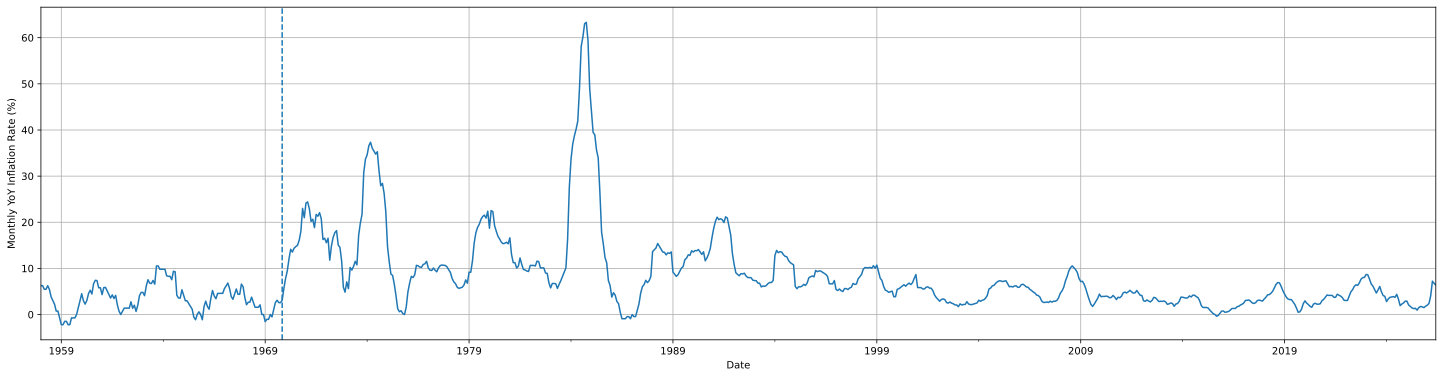

In [32]:
# we can show that in the plot

plt.figure(figsize=(25, 6))
INF_rate.plot(label = 'Actual Data')
plt.axvline(pd.Timestamp(INF_rate.index[142]), linestyle = '--')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.grid(True)
plt.show()

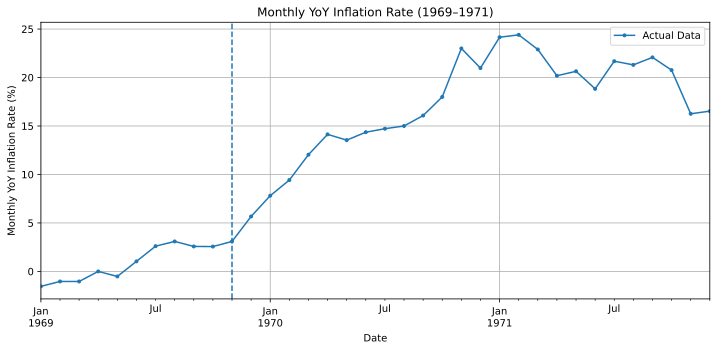

In [34]:
# 1. Slice the time series for the desired date range
INF_sub = INF_rate.loc['1969-01-01':'1971-12-31']

# 2. Plot the zoomed-in subset
plt.figure(figsize=(12, 5))
INF_sub.plot(label='Actual Data', marker='o', markersize=3)
plt.axvline(pd.Timestamp(INF_rate.index[142]), linestyle = '--')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.title('Monthly YoY Inflation Rate (1969–1971)')
plt.grid(True)
plt.legend()

plt.show()

### ACF and P-ACF

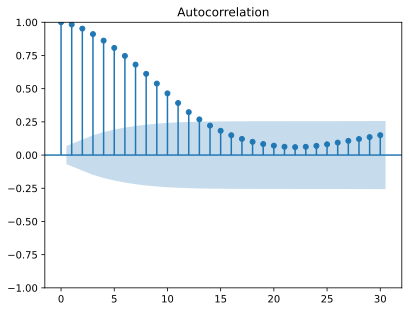

In [35]:
plot_acf(INF_rate)
plt.show()

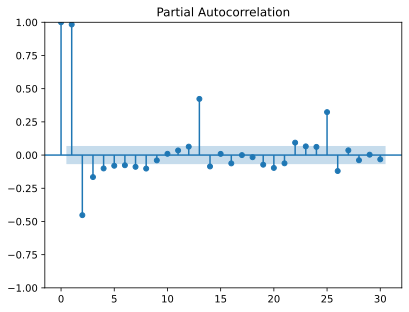

In [38]:
plot_pacf(INF_rate)
plt.show()

ACF plot - shows a slow and smooth decay. This tells us that it is of an autoregressive (AR) process. 

PACF plot - shows a two very large spikes at lag 1 and 2, then everything drops inside the shaded confidence band. This tells us that it is of an AR(p) process


We have an AR(2) model as a reasonable starting point.\
Inflation rate is well explained by a direct dependence on the previous 1-2 months' values. 

### Naive and Seasonal Naive

In [3]:
from model_lib.model_naive import *

In [50]:
# From the data set

INF_data.index = pd.to_datetime(INF_data.index)
INF_data = INF_data.asfreq('MS')  # Set frequency to monthly start
INF_data.head()


,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,TargetRRP
Date,,,,,
1958-01-01,6.25000,2.0,NaN,NaN,NaN
1958-02-01,6.25000,2.0,NaN,NaN,NaN
1958-03-01,5.46875,2.0,NaN,NaN,NaN
1958-04-01,5.46875,2.0,NaN,NaN,NaN
1958-05-01,6.25000,2.0,NaN,NaN,NaN


In [51]:
n_splits = 5
months_forecast = 12
test_size = months_forecast
target_variable = 'InflationRate'
INF_train = INF_data.iloc[:-test_size]
INF_test = INF_data.iloc[-test_size:]

In [54]:
forecast_test(INF_train, forecast_fn = naive_forecast, n_splits = n_splits, test_size= test_size, target_col = target_variable, progress= True)

Model: naive_forecast
Folds: 5
Test Size: 12


naive_forecast:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,1.311391,1.055347,-1.805766
2,0.988967,0.740575,-0.179733
3,1.492747,1.220889,-1.209910
4,1.479384,1.314080,-1.926316
5,1.632575,1.484359,-2.438819


In [55]:
forecast_test(INF_train, forecast_fn = seasonal_naive_forecast, n_splits = n_splits, test_size= test_size, target_col = target_variable, progress= True)

Model: seasonal_naive_forecast
Folds: 5
Test Size: 12


seasonal_naive_forecast:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,1.663316,1.524544,-3.513743
2,1.378721,1.189344,-1.292837
3,3.596012,3.193425,-11.824617
4,3.381186,3.002995,-14.286123
5,2.150826,1.868627,-4.968621


In [58]:
n_test_forecast = naive_forecast(INF_train, months_ahead=months_forecast, target_col = target_variable)
Naive_test = pd.DataFrame(eval_metrics(INF_test[target_variable], n_test_forecast), index = ['Naive Forecast'])

Naive_test

,RMSE,MAE,R2
Naive Forecast,2.864234,1.881748,-0.67007


In [ ]:
sn_test_forecast = seasonal_naive_forecast(INF_train, months_ahead=months_forecast, target_col = target_variable)
Seasonal_Naive_test = pd.DataFrame(eval_metrics(INF_test[target_variable], sn_test_forecast), index = ['Seasonal Naive Forecast'])

Seasonal_Naive_test

,RMSE,MAE,R2
Seasonal Naive Forecast,3.06522,2.332447,-0.912674


## Naive (and Seasonal) Forecast

In [61]:
naive = naive_forecast(INF_data, months_ahead=months_forecast, target_col = target_variable)
naive = pd.DataFrame(naive, columns= ['Naive Forecasting']) 

In [62]:
naive.head()

,Naive Forecasting
2026-07-01,6.362922
2026-08-01,6.362922
2026-09-01,6.362922
2026-10-01,6.362922
2026-11-01,6.362922


In [63]:
seasonal_naive = seasonal_naive_forecast(INF_data, months_ahead=months_forecast, target_col = target_variable)
seasonal_naive = pd.DataFrame(seasonal_naive, columns= ['Seasonal Naive Forecasting'])

seasonal_naive.head()

,Seasonal Naive Forecasting
2026-07-01,0.948617
2026-08-01,1.500790
2026-09-01,1.741884
2026-10-01,1.660079
2026-11-01,1.496063


In [64]:
output_dir

'/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/output_files'

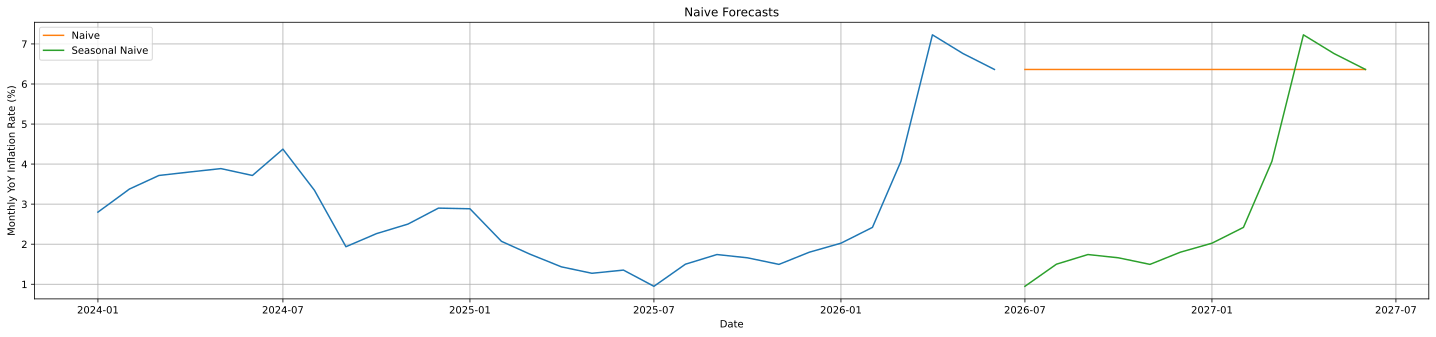

In [68]:
plt.figure(figsize = (25, 5))
plt.plot(INF_data[target_variable]['2024':])
plt.title('Naive Forecasts')
plt.plot(naive, label = 'Naive')
plt.plot(seasonal_naive, label = 'Seasonal Naive')
plt.xlabel('Date')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.savefig(output_dir + '/naive_forecast.png', dpi = 300, bbox_inches = 'tight')
plt.show()

I want to see how well these baseline models fit with the actual data

In [70]:
from model_lib.baseline_plots import *

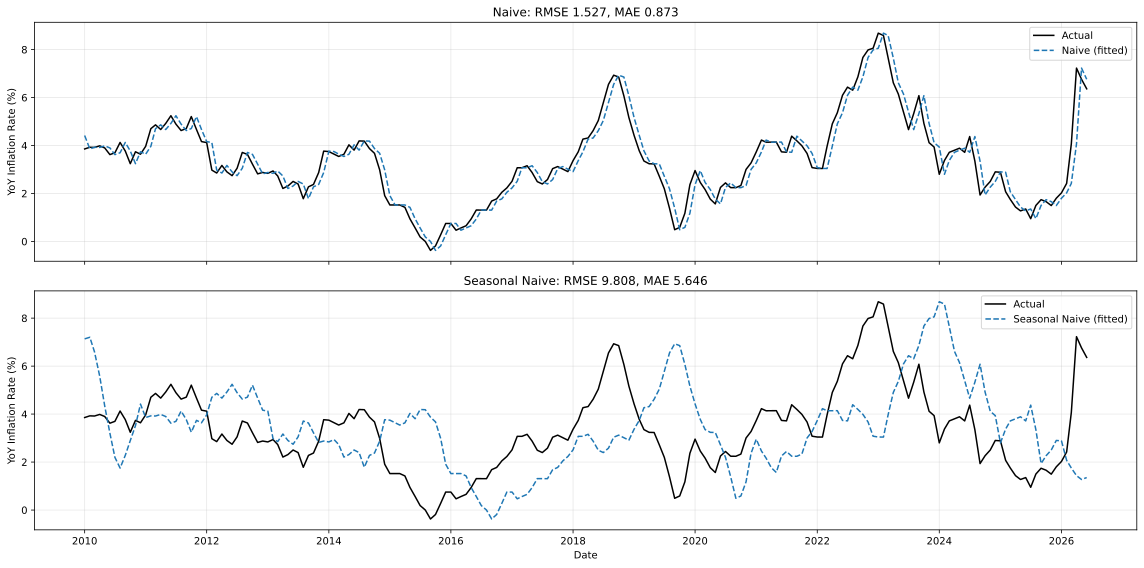

,RMSE,MAE
Naive,1.527151,0.872831
Seasonal Naive,9.807690,5.645560


In [71]:
metrics = plot_fitted(INF_data, target_col="InflationRate", start="2010")
metrics   # RMSE and MAE over the full sample

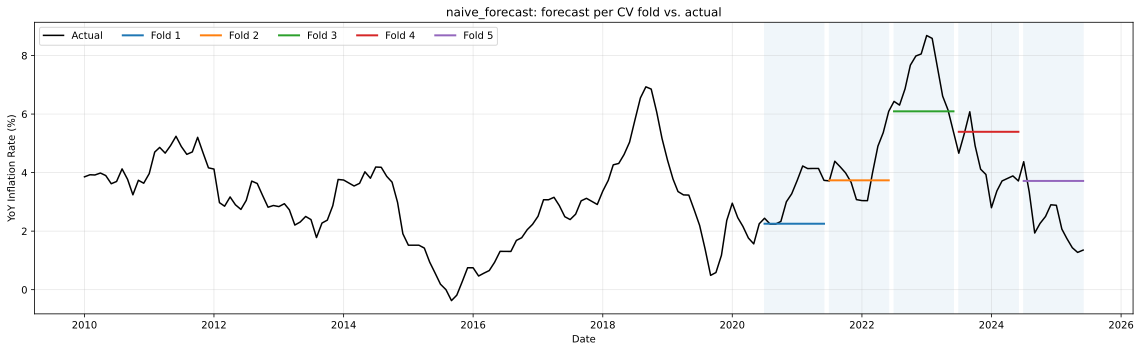

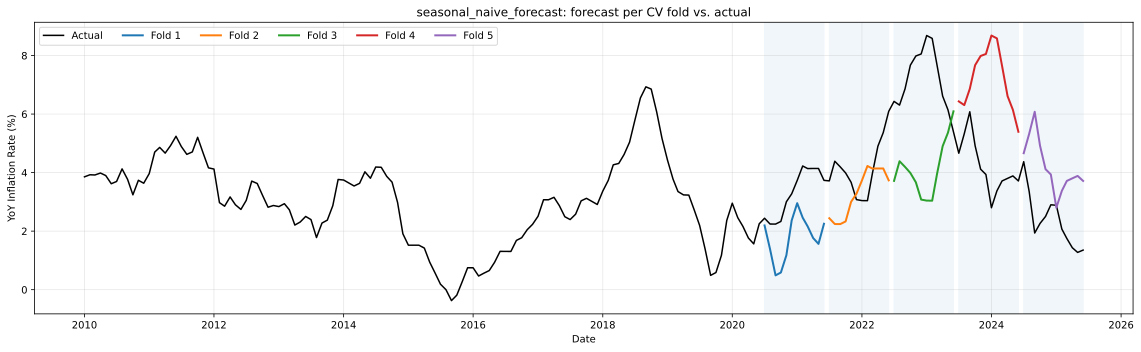

In [73]:
plot_cv_forecasts(INF_train, naive_forecast, n_splits=5, test_size=12,
                  target_col="InflationRate", start="2010")
plot_cv_forecasts(INF_train, seasonal_naive_forecast, n_splits=5, test_size=12,
                  target_col="InflationRate", start="2010")

## ARIMA models

In [5]:
# importing the dataset

INF_data = pd.read_csv("/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/data_set/processed/Combined_Macro_Data.csv").set_index(['Date'])
INF_data.index = pd.to_datetime(INF_data.index)
INF_rate = INF_data['InflationRate'].dropna()

In [6]:
# import the ARIMA models

from model_lib.model_arima import *

In [7]:
n_splits = 5
months_ahead = 12 # one year forecast horizon
test_size = months_ahead

INF_train = INF_rate[:-test_size]
INF_test = INF_rate[-test_size:]

## We now test the models

In [8]:
arima_results = arima_test(ts_data=INF_train, n_splits=n_splits, test_size=test_size, target_col="InflationRate")
sarima_results = sarima_test(ts_data=INF_train, n_splits=n_splits, test_size=test_size, target_col="InflationRate")
sarimax_results = sarimax_test(ts_data=INF_train, n_splits=n_splits, test_size=test_size, target_col="InflationRate")

print("ARIMA:");display(arima_results);print("SARIMA:");display(sarima_results);print("SARIMAX:");display(sarimax_results)

Folds: 5
Test Size: 12


ARIMA:   0%|          | 0/5 [00:00<?, ?fold/s]

Folds: 5
Test Size: 12


sarima:   0%|          | 0/5 [00:00<?, ?fold/s]

Folds: 5
Test Size: 12


...

,RMSE,MAE,R2
Fold,,,
1,0.818147,0.694192,-0.092068
2,1.238045,0.905442,-0.848815
3,0.994336,0.800722,0.019453
4,0.676431,0.485283,0.388204
5,1.525304,1.379121,-2.001762


SARIMA:


,RMSE,MAE,R2
Fold,,,
1,0.818147,0.694192,-0.092068
2,1.238045,0.905442,-0.848815
3,0.994336,0.800722,0.019453
4,0.676431,0.485283,0.388204
5,1.525304,1.379121,-2.001762


SARIMAX:


,RMSE,MAE,R2
Fold,,,
1,1.009342,0.834683,-0.662127
2,1.564241,1.218053,-1.951400
3,0.905506,0.687203,0.186823
4,0.936552,0.858689,-0.172796
5,0.871152,0.649368,0.020845


In [9]:
summary = pd.concat(
    {
        "ARIMA": arima_results.mean(),
        "SARIMA": sarima_results.mean(),
        "SARIMAX": sarimax_results.mean(),
    },
    axis=1
).T

summary

,RMSE,MAE,R2
ARIMA,1.050453,0.852952,-0.506998
SARIMA,1.050453,0.852952,-0.506998
SARIMAX,1.057359,0.849599,-0.515731


In [10]:
# DataFrame version (for SARIMAX / SARIMAX-lagged - needs exogenous columns)
INF_data_clean = INF_data.dropna()          # align all columns the same way inf_rate was cleaned
INF_train_full = INF_data_clean[:-test_size]
INF_test_full = INF_data_clean[-test_size:]

In [12]:
sarimax_lagged_test(ts_data=INF_train_full, test_size = test_size, n_splits=n_splits, target_col="InflationRate", lag=12, progress=True)

Folds: 5
Test Size: 12


sarimax_lagged:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,0.502294,0.417171,0.588374
2,1.091392,0.697297,-0.436752
3,2.564905,2.288491,-5.524461
4,0.878369,0.805319,-0.031605
5,1.064868,0.893270,-0.463036


In [13]:
print(len(INF_train), INF_train.index[0], INF_train.index[-1])
print(len(INF_train_full), INF_train_full.index[0], INF_train_full.index[-1])

810 1958-01-01 00:00:00 2025-06-01 00:00:00
246 2005-01-01 00:00:00 2025-06-01 00:00:00


In [14]:
INF_data[['UnemploymentRate', 'USD_PHP', 'DubaiCrude', 'TargetRRP']].apply(lambda c: c.first_valid_index())

UnemploymentRate   2005-01-01
USD_PHP            1958-01-01
DubaiCrude         1992-01-01
TargetRRP          1986-01-01
dtype: datetime64[us]

In [15]:
INF_rate_matched = INF_train_full['InflationRate']   # same 2005-2025 dates, target-only

arima_test(INF_rate_matched, n_splits, test_size, target_col=None)

Folds: 5
Test Size: 12


ARIMA:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,1.208779,1.037350,-1.383859
2,1.263080,0.945001,-0.924341
3,1.027456,0.857212,-0.046955
4,0.834061,0.713106,0.069847
5,1.587997,1.436875,-2.253586


In [17]:
display(sarima_test(INF_rate_matched, n_splits, test_size, target_col=None))
display(sarimax_test(INF_train_full, n_splits, test_size, target_col="InflationRate"))
display(sarimax_lagged_test(INF_train_full, n_splits, test_size, target_col="InflationRate"))

Folds: 5
Test Size: 12


sarima:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,1.208779,1.037350,-1.383859
2,1.263080,0.945001,-0.924341
3,1.027456,0.857212,-0.046955
4,0.834061,0.713106,0.069847
5,1.587997,1.436875,-2.253586


Folds: 5
Test Size: 12


sarimax:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,0.714513,0.606146,0.167073
2,1.324862,0.883744,-1.117201
3,1.886108,1.611881,-2.528054
4,0.494685,0.386711,0.672797
5,1.678452,1.412106,-2.634803


Folds: 5
Test Size: 12


sarimax_lagged:   0%|          | 0/5 [00:00<?, ?fold/s]

,RMSE,MAE,R2
Fold,,,
1,0.502294,0.417171,0.588374
2,1.091392,0.697297,-0.436752
3,2.564905,2.288491,-5.524461
4,0.878369,0.805319,-0.031605
5,1.064868,0.893270,-0.463036


In [18]:
lagged_sarimax_results = sarimax_lagged_test(ts_data=INF_train_full, n_splits=n_splits, test_size=test_size, target_col="InflationRate")

Folds: 5
Test Size: 12


sarimax_lagged:   0%|          | 0/5 [00:00<?, ?fold/s]

In [19]:
# ARIMA / SARIMA - target only, still fine to pass the full frame since they extract the column themselves
arima_model, arima_pred, _ = arima_forecast(INF_train_full, test_size, target_col="InflationRate")
sarima_model, sarima_pred, _ = sarima_forecast(INF_train_full, test_size, target_col="InflationRate")

# SARIMAX / lagged SARIMAX - need the exogenous columns
sarimax_model, sarimax_pred, _ = sarimax_forecast(INF_train_full, test_size, target_col="InflationRate")
lagged_model, lagged_pred, _ = sarimax_lagged_forecast(INF_train_full, test_size, target_col="InflationRate")

final_scores = pd.concat([
    pd.DataFrame(eval_metrics(INF_test_full['InflationRate'], arima_pred), index=['ARIMA']),
    pd.DataFrame(eval_metrics(INF_test_full['InflationRate'], sarima_pred), index=['SARIMA']),
    pd.DataFrame(eval_metrics(INF_test_full['InflationRate'], sarimax_pred), index=['SARIMAX']),
    pd.DataFrame(eval_metrics(INF_test_full['InflationRate'], lagged_pred), index=['SARIMAX (Lagged)']),
])
final_scores

,RMSE,MAE,R2
ARIMA,2.833898,1.841018,-0.634880
SARIMA,2.833898,1.841018,-0.634880
SARIMAX,1.473550,1.043251,0.557974
SARIMAX (Lagged),1.662598,1.088097,0.437280


# Forecast with SARIMAX

In [10]:
# Use ALL matched data (train + test combined) - no more held-out set needed at this stage
full_data = INF_data.dropna()  # same 2005-01-01 to 2025-06-01 window as your final test

sarimax_model, sarimax_pred, sarimax_conf = sarimax_forecast(ts_data=full_data, n_forecast=months_ahead, target_col="InflationRate")
sarimax_pred = pd.Series(sarimax_pred, name='SARIMAX', index=pd.date_range(full_data.index[-1], periods=months_ahead+1, freq='MS')[1:])

lagged_model, lagged_pred, lagged_conf = sarimax_lagged_forecast(ts_data=full_data, n_forecast=months_ahead, target_col="InflationRate")
lagged_pred = pd.Series(lagged_pred, name='SARIMAX (Lagged)', index=pd.date_range(full_data.index[-1], periods=months_ahead+1, freq='MS')[1:])

In [21]:
# building confidence intervals for the forecasts

sarimax_low = pd.Series(sarimax_conf[:, 0], name='SARIMAX Low', index=sarimax_pred.index)
sarimax_high = pd.Series(sarimax_conf[:, 1], name='SARIMAX High', index=sarimax_pred.index)

lagged_low = pd.Series(lagged_conf[:, 0], name='Lagged Low', index=lagged_pred.index)
lagged_high = pd.Series(lagged_conf[:, 1], name='Lagged High', index=lagged_pred.index)

full_forecast = pd.concat([sarimax_pred, sarimax_low, sarimax_high,lagged_pred, lagged_low, lagged_high], axis=1)
full_forecast.to_csv('/Users/aidz/Desktop/inflation forecasting project/my-attempt/output/forecasts/full_forecast_comparison_1.csv')

full_forecast

,SARIMAX,SARIMAX Low,SARIMAX High,SARIMAX (Lagged),Lagged Low,Lagged High
2026-07-01,6.606588,5.873660,7.339515,6.723073,5.985948,7.460198
2026-08-01,6.357162,5.110576,7.603748,6.456704,5.193248,7.720160
2026-09-01,6.698205,5.116629,8.279781,6.757746,5.186002,8.329489
2026-10-01,6.835865,4.991168,8.680562,6.848105,5.019327,8.676883
2026-11-01,7.110751,5.046741,9.174762,7.171384,5.127141,9.215628
2026-12-01,6.570995,4.318161,8.823829,6.752386,4.519756,8.985015
2027-01-01,6.546522,4.127766,8.965279,6.599268,4.199170,8.999366
2027-02-01,6.529066,3.962458,9.095674,6.517673,3.966589,9.068757
2027-03-01,5.287841,2.588138,7.987543,4.967994,2.279457,7.656531
2027-04-01,2.887166,0.066720,5.707611,2.834985,0.020362,5.649607


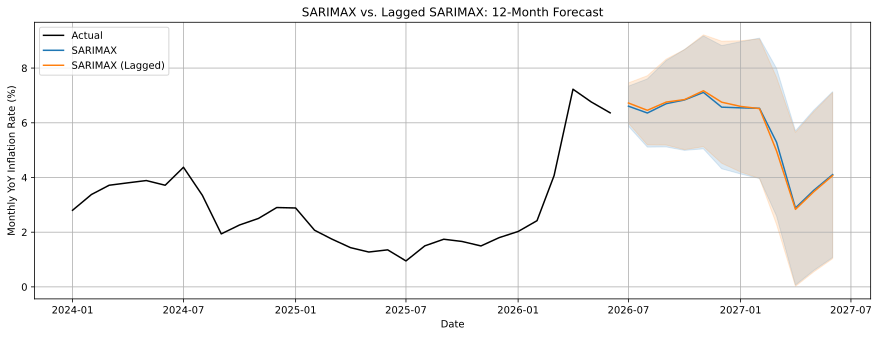

In [25]:
plt.figure(figsize=(15, 5))

plt.plot(full_data['InflationRate']['2024':], label='Actual', color='black')

plt.plot(sarimax_pred, label='SARIMAX', color='tab:blue')
plt.fill_between(sarimax_pred.index, sarimax_low, sarimax_high, color='tab:blue', alpha=0.15)

plt.plot(lagged_pred, label='SARIMAX (Lagged)', color='tab:orange')
plt.fill_between(lagged_pred.index, lagged_low, lagged_high, color='tab:orange', alpha=0.15)

plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.title('SARIMAX vs. Lagged SARIMAX: 12-Month Forecast')
plt.legend()
plt.savefig('/Users/aidz/Documents/Projects/Inflation-Forecast-Regression/output_files/sarimax_vs_lagged_forecast_1.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
target_date = pd.Timestamp('2026-03-01')

if target_date in full_forecast.index:
    print(full_forecast.loc[target_date])
else:
    print(f"{target_date.date()} is not in the forecast range ({full_forecast.index[0].date()} to {full_forecast.index[-1].date()})")

2026-03-01 is not in the forecast range (2026-07-01 to 2027-06-01)


In [29]:
sarimax_pred.loc['2026-8-01'] # inflation rate forecast for October 2026 using SARIMAX model

np.float64(6.357162277679068)

In [30]:
lagged_pred.loc['2026-8-01'] # inflation rate forecast for October 2026 using lagged SARIMAX model

np.float64(6.4567038738608495)

In [31]:
full_forecast.loc['2026-09-01'] # inflation rate forecast for October 2026 using both models

SARIMAX             6.698205
SARIMAX Low         5.116629
SARIMAX High        8.279781
SARIMAX (Lagged)    6.757746
Lagged Low          5.186002
Lagged High         8.329489
Name: 2026-09-01 00:00:00, dtype: float64

## In-sample fit check

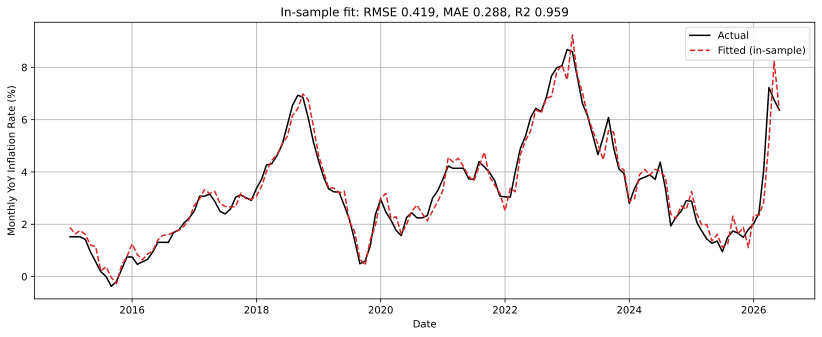

{'RMSE': np.float64(0.4187797016777306),
 'MAE': 0.28795616845211763,
 'R2': 0.9592383310648758}

In [11]:
sarimax_model, sarimax_pred, sarimax_conf = sarimax_forecast(
    ts_data=full_data, n_forecast=months_ahead, target_col="InflationRate"
)

plot_sarimax_fitted(sarimax_model, full_data, target_col="InflationRate", exog_lag=0, start="2015")

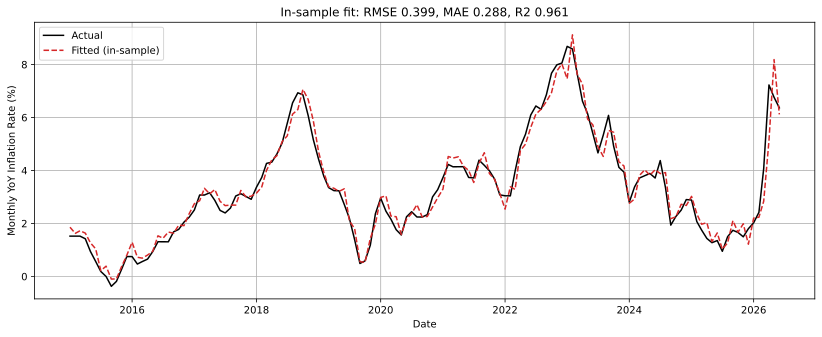

{'RMSE': np.float64(0.3990968153714409),
 'MAE': 0.28832917563483185,
 'R2': 0.9612669734570095}

In [12]:
lagged_model, lagged_pred, lagged_conf = sarimax_lagged_forecast(
    ts_data=full_data, n_forecast=months_ahead, target_col="InflationRate"
)

plot_sarimax_fitted(lagged_model, full_data, target_col="InflationRate", exog_lag=12, start="2015")